# Parametric Studies - MyBESS Generalized Sweep

This notebook always starts from the non-initialized dynamic model `MyBESS`. Set `REINITIALIZE_EACH_CASE` to choose whether the model is initialized once before the sweep, or reinitialized after each parameter update.

In [1]:
include("../FullWorkflow/scripts/dictionaries.jl")
include("../FullWorkflow/scripts/helpers.jl")
include("scripts/parametric_study_helpers.jl")
include("scripts/single_model_initialization.jl")

using .FullWorkflowHelpers
using .ModelInitialization
using OMJulia, CSV, DataFrames

## User Configuration

In [2]:
BASE_MODEL = "MyBESS"
BASE_MODEL_FILE = abspath("../FullWorkflow/models/MyBESS.mo")

DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

SWEEP_COMPONENT = "BESS"
SWEEP_PARAMETER = "RPu"
SWEEP_VALUES = [0.0, 0.1, 0.3, 0.5]

REINITIALIZE_EACH_CASE = true

INIT_MODEL_BY_COMPONENT = Dict{String, String}(
    # "generatorSynchronous" => "GeneratorSynchronousInt_INIT",
)

# Leave empty to disable slack-specific handling.
SLACK_COMPONENT = ""

PLOT_VARIABLE = "BESS.terminal.V.im"
OUTPUT_DIR = abspath("outputs/generalized_parametric_runs");

## Prepare OpenModelica Session

In [3]:
MODEL_OUTPUT_DIR = joinpath(OUTPUT_DIR, "modelica")
RESULT_OUTPUT_DIR = joinpath(OUTPUT_DIR, "results")

isfile(BASE_MODEL_FILE) || error("Base model file not found: $BASE_MODEL_FILE")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")

rm(OUTPUT_DIR; recursive = true, force = true)
mkpath(MODEL_OUTPUT_DIR)
mkpath(RESULT_OUTPUT_DIR)

StudyOMC = OMJulia.OMCSession()
load_modelica_file!(
    StudyOMC,
    BASE_MODEL_FILE,
    MODELICA_PKG_PATH,
    DYNAWO_PKG_PATH,
)
check_user_configuration_single(StudyOMC;
    model = BASE_MODEL,
    sweep_component = SWEEP_COMPONENT,
    sweep_parameter = SWEEP_PARAMETER,
    slack_component = SLACK_COMPONENT,
    init_model_by_component = INIT_MODEL_BY_COMPONENT,
)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.mcwNgpIsyS"


Configuration checked successfully


## Initialize the Base Case

In [4]:

if !REINITIALIZE_EACH_CASE
    base_initialized_case = initialize_loaded_model(
        StudyOMC;
        source_model = BASE_MODEL,
        case_name = BASE_MODEL,
        output_dir = OUTPUT_DIR,
        modelica_package_path = MODELICA_PKG_PATH,
        dynawo_package_path = DYNAWO_PKG_PATH,
        init_model_by_component = INIT_MODEL_BY_COMPONENT,
        slack_component = SLACK_COMPONENT,
    )

    base_initialized_model = base_initialized_case.initialized_model
    base_initialized_model_file = base_initialized_case.initialized_model_file
end

OMJulia.quit(StudyOMC)


## Run the Parameter Sweep

In [5]:
sweep_results = DataFrame[]

for value in SWEEP_VALUES
    label = case_label(value)
    parameter_name = replace(SWEEP_PARAMETER, "." => "_")
    case_model = join([BASE_MODEL, SWEEP_COMPONENT, parameter_name, label], "_")
    selected_resultfile = joinpath(RESULT_OUTPUT_DIR, case_model * "_selected.csv")

    StudyOMC = OMJulia.OMCSession()

    if REINITIALIZE_EACH_CASE
        load_modelica_file!(
            StudyOMC,
            BASE_MODEL_FILE,
            MODELICA_PKG_PATH,
            DYNAWO_PKG_PATH,
        )
        omc_call(
            StudyOMC,
            "setParameterValue($(BASE_MODEL), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
            parsed = false,
        )

        initialized_case = initialize_loaded_model(
            StudyOMC;
            source_model = BASE_MODEL,
            case_name = case_model,
            output_dir = OUTPUT_DIR,
            modelica_package_path = MODELICA_PKG_PATH,
            dynawo_package_path = DYNAWO_PKG_PATH,
            init_model_by_component = INIT_MODEL_BY_COMPONENT,
            slack_component = SLACK_COMPONENT,
        )

        simulation_model = initialized_case.initialized_model
        result_prefix = simulation_model
    else
        load_modelica_file!(
            StudyOMC,
            base_initialized_model_file,
            MODELICA_PKG_PATH,
            DYNAWO_PKG_PATH,
        )
        omc_call(
            StudyOMC,
            "setParameterValue($(base_initialized_model), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
            parsed = false,
        )

        simulation_model = base_initialized_model
        result_prefix = case_model
    end

    ModelicaSystem(
        StudyOMC,
        nothing,
        simulation_model,
        [MODELICA_PKG_PATH, DYNAWO_PKG_PATH],
    )

    simflags = simulation_flags_without_log_stats(StudyOMC, simulation_model)
    omc_call(
        StudyOMC,
        "simulate($simulation_model, outputFormat=\"csv\", fileNamePrefix=\"$result_prefix\", simflags=\"$simflags\")",
        parsed = false,
    )

    raw_resultfile = joinpath(getWorkDirectory(StudyOMC), result_prefix * "_res.csv")
    df = DataFrame(CSV.File(raw_resultfile; select = ["time", PLOT_VARIABLE]))
    df[!, :case] .= label
    df[!, :parameter_value] .= value

    CSV.write(selected_resultfile, df)
    push!(sweep_results, df)
    OMJulia.quit(StudyOMC)

    println("Finished case $label with $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
end

sweep_df = vcat(sweep_results...)

println("Stored selected result files in: ", RESULT_OUTPUT_DIR)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.EYk37AFm8V"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.YcdVis1I15"


Finished case 0p0 with BESS.RPu = 0.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.xeNAyssIt5"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.hWudGOjek8"


...

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.hPq2vD75Qj"


Finished case 0p3 with BESS.RPu = 0.3


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.lmff1QHYJR"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.GFuWS0FdF8"


Finished case 0p5 with BESS.RPu = 0.5
Stored selected result files in: /home/clarafercas/dynawo-notebooks/OpenModelica_only_users/ParametricStudies/outputs/generalized_parametric_runs/results

## Compare Sweep Results

WebIO._IJuliaInit()

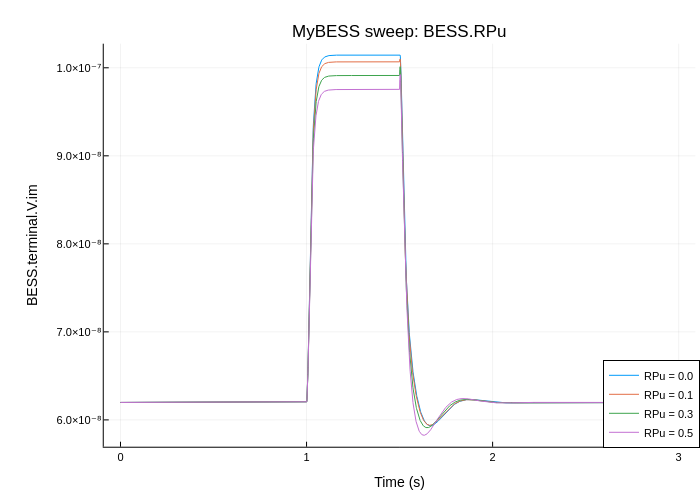

In [6]:
using Plots

plotlyjs()
p = plot(
    title = "MyBESS sweep: $SWEEP_COMPONENT.$SWEEP_PARAMETER",
    xlabel = "Time (s)",
    ylabel = PLOT_VARIABLE,
)

for case_group in groupby(sweep_df, :case)
    value = first(case_group.parameter_value)
    plot!(
        p,
        case_group.time,
        case_group[!, PLOT_VARIABLE],
        label = "$SWEEP_PARAMETER = $value",
    )
end

plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)